Me apetecía hacer la idea original. Ya que había buscado los datasets
Necesito:
- Ganadores oscar actor/actriz
- Año
- Edad a la que lo ganaron
- Año en que lo ganaron (edad oscar - edad de nacimiento)
También los actores tienen un id de imdb. Si puedo hacer el merge por ahí es más fácil

In [1]:
import pandas as pd

In [2]:
# Esto ya lo tenía hecho en ExplorandoDatosCine
oscars = pd.read_csv (r"C:\Users\NaiaJon\Documents\Naia\BootcampDataScience\Datos EDA\data_cine\Oscar_Awards.csv", sep="\t")
oscars.info()

<class 'pandas.DataFrame'>
RangeIndex: 12014 entries, 0 to 12013
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Ceremony             12014 non-null  int64 
 1   Year                 12014 non-null  str   
 2   Class                12014 non-null  str   
 3   CanonicalCategory    12014 non-null  str   
 4   Category             12014 non-null  str   
 5   NomId                11482 non-null  str   
 6   Film                 10753 non-null  str   
 7   FilmId               10753 non-null  str   
 8   Name                 10829 non-null  str   
 9   Nominees             11661 non-null  str   
 10  NomineeIds           11134 non-null  str   
 11  Winner               3476 non-null   object
 12  Detail               3171 non-null   str   
 13  Note                 616 non-null    str   
 14  Citation             1183 non-null   str   
 15  MultifilmNomination  40 non-null     object
dtypes: int64(1), ob

In [3]:
acting  = oscars[(oscars["Class"] == "Acting")]
acting.sample(5)


,Ceremony,Year,Class,CanonicalCategory,Category,NomId,Film,FilmId,Name,Nominees,NomineeIds,Winner,Detail,Note,Citation,MultifilmNomination
7364,63,1990,Acting,ACTOR IN A SUPPORTING ROLE,ACTOR IN A SUPPORTING ROLE,an0053090,Dances With Wolves,tt0099348,Graham Greene,Graham Greene,nm0001295,NaN,Kicking Bird,NaN,NaN,NaN
2072,19,1946,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0047574,Henry V,tt0036910,Laurence Olivier,Laurence Olivier,nm0000059,NaN,Henry V,NaN,NaN,NaN
6647,57,1984,Acting,ACTOR IN A LEADING ROLE,ACTOR IN A LEADING ROLE,an0052817,Amadeus,tt0086879,Tom Hulce,Tom Hulce,nm0001371,NaN,Wolfgang Amadeus Mozart,NaN,NaN,NaN
708,11,1938,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0049848,Angels with Dirty Faces,tt0029870,James Cagney,James Cagney,nm0000010,NaN,Rocky Sullivan,NaN,NaN,NaN
8417,71,1998,Acting,ACTRESS IN A SUPPORTING ROLE,ACTRESS IN A SUPPORTING ROLE,an0057196,Little Voice,tt0147004,Brenda Blethyn,Brenda Blethyn,nm0000950,NaN,Mari,NaN,NaN,NaN


In [4]:
print(acting ["CanonicalCategory"].unique())
print(acting ["Category"].unique())

<StringArray>
[     'ACTOR IN A LEADING ROLE',    'ACTRESS IN A LEADING ROLE',
   'ACTOR IN A SUPPORTING ROLE', 'ACTRESS IN A SUPPORTING ROLE']
Length: 4, dtype: str
<StringArray>
[                       'ACTOR',                      'ACTRESS',
   'ACTOR IN A SUPPORTING ROLE', 'ACTRESS IN A SUPPORTING ROLE',
      'ACTOR IN A LEADING ROLE',    'ACTRESS IN A LEADING ROLE']
Length: 6, dtype: str


In [5]:
acting = acting [['Year','CanonicalCategory', 'NomId', 'Name', 'NomineeIds', 'Winner']]

In [6]:
acting.info()

<class 'pandas.DataFrame'>
Index: 1855 entries, 0 to 11895
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Year               1855 non-null   str   
 1   CanonicalCategory  1855 non-null   str   
 2   NomId              1855 non-null   str   
 3   Name               1855 non-null   str   
 4   NomineeIds         1855 non-null   str   
 5   Winner             377 non-null    object
dtypes: object(1), str(5)
memory usage: 101.4+ KB


In [7]:
#Por otro lado la info de IMdB de nombres 
#IMDB names. 
names = pd.read_csv (r"C:\Users\NaiaJon\Documents\Naia\BootcampDataScience\Datos EDA\data_cine\name.basics.csv", sep="\t")
names.info()

<class 'pandas.DataFrame'>
RangeIndex: 15178050 entries, 0 to 15178049
Data columns (total 6 columns):
 #   Column             Dtype
---  ------             -----
 0   nconst             str  
 1   primaryName        str  
 2   birthYear          str  
 3   deathYear          str  
 4   primaryProfession  str  
 5   knownForTitles     str  
dtypes: str(6)
memory usage: 694.8 MB


In [8]:
names.sample(5)

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
4777487,nm14141869,Aaron Burrows,\N,\N,\N,\N
5271792,nm1472982,Isabella Graffi,\N,\N,actress,"tt0229545,tt0297525"
12258506,nm6273962,Takehiko Nishida,\N,\N,"production_department,miscellaneous","tt7236034,tt4054952,tt5544384,tt8091892"
8586833,nm2000661,Nina Stone,\N,\N,"actress,producer,stunts","tt0406038,tt0402625"
10472269,nm4139101,Lucía Martín,\N,\N,"art_department,art_director,production_designer","tt3774894,tt1764576,tt6566176,tt10573436"


In [9]:
#comprobar si como parece nconst es el nomineeId de la otra tabla. Compruebo el primero de la otra
names[names ['nconst'] == "nm0000027"]

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
26,nm0000027,Alec Guinness,1914,2000,"actor,writer,soundtrack","tt0076759,tt0050212,tt0041546,tt0051739"


In [10]:
# Sólo necesito nconst y el año de nacimiento
names = names [['nconst', 'birthYear']]


In [11]:
# Añadir estas dos columnas al dataset de acting
names.rename (columns= {'nconst': 'NomineeIds'}, inplace=True)
names.info()


<class 'pandas.DataFrame'>
RangeIndex: 15178050 entries, 0 to 15178049
Data columns (total 2 columns):
 #   Column      Dtype
---  ------      -----
 0   NomineeIds  str  
 1   birthYear   str  
dtypes: str(2)
memory usage: 231.6 MB


In [12]:
acting = acting.merge (names, how='left', on='NomineeIds')

In [13]:
acting.info()

<class 'pandas.DataFrame'>
RangeIndex: 1855 entries, 0 to 1854
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Year               1855 non-null   str   
 1   CanonicalCategory  1855 non-null   str   
 2   NomId              1855 non-null   str   
 3   Name               1855 non-null   str   
 4   NomineeIds         1855 non-null   str   
 5   Winner             377 non-null    object
 6   birthYear          1855 non-null   str   
dtypes: object(1), str(6)
memory usage: 101.6+ KB


In [14]:
acting['Winner'].unique()
acting.fillna (False, inplace=True)

,Year,CanonicalCategory,NomId,Name,NomineeIds,Winner,birthYear
0,1927/28,ACTOR IN A LEADING ROLE,an0051251,Richard Barthelmess,nm0001932,False,1895
1,1927/28,ACTOR IN A LEADING ROLE,an0051252,Richard Barthelmess,nm0001932,False,1895
2,1927/28,ACTOR IN A LEADING ROLE,an0051250a,Emil Jannings,nm0417837,True,1884
3,1927/28,ACTOR IN A LEADING ROLE,an0051250b,Emil Jannings,nm0417837,True,1884
4,1927/28,ACTRESS IN A LEADING ROLE,an0051255,Louise Dresser,nm0237571,False,1878
...,...,...,...,...,...,...,...
1850,2024,ACTRESS IN A SUPPORTING ROLE,fake_nomid028,Monica Barbaro,nm4834815,False,1989
1851,2024,ACTRESS IN A SUPPORTING ROLE,fake_nomid026,Ariana Grande,nm3812858,False,1993
1852,2024,ACTRESS IN A SUPPORTING ROLE,fake_nomid029,Felicity Jones,nm0428065,False,1983
1853,2024,ACTRESS IN A SUPPORTING ROLE,fake_nomid027,Isabella Rossellini,nm0000618,False,1952


In [15]:
#Comprobar tipos
acting.dtypes

Year                    str
CanonicalCategory       str
NomId                   str
Name                    str
NomineeIds              str
Winner               object
birthYear               str
dtype: object

In [16]:
# Pasa lo mismo que me había pasado al pasar los premios a las pelis: Winner no es booleano y Year y BirthYear
# son strings. Además year está en algunos años 1927/28.
# Nos quedamos con los 4 primeros dígitos del año.
acting ["Year"] = acting["Year"].str [:4]

In [17]:
acting ["Year"].unique()

<StringArray>
['1927', '1928', '1929', '1930', '1931', '1932', '1934', '1935', '1936',
 '1937', '1938', '1939', '1940', '1941', '1942', '1943', '1944', '1945',
 '1946', '1947', '1948', '1949', '1950', '1951', '1952', '1953', '1954',
 '1955', '1956', '1957', '1958', '1959', '1960', '1961', '1962', '1963',
 '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972',
 '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981',
 '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990',
 '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999',
 '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
 '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
 '2018', '2019', '2020', '2021', '2022', '2023', '2024']
Length: 97, dtype: str

In [18]:
acting ["Year"] = acting ["Year"].astype (int)
acting ["birthYear"] = acting ["birthYear"].astype (int)
acting ["Winner"] = acting ["Winner"].astype (bool)

ValueError: invalid literal for int() with base 10: '\\N'

In [19]:
# Parece que faltan algunos años de nacimiento
acting[acting["birthYear"]== '\\N']

,Year,CanonicalCategory,NomId,Name,NomineeIds,Winner,birthYear
1446,2004,ACTRESS IN A LEADING ROLE,an0056553,Catalina Sandino Moreno,nm1503432,False,\N
1453,2004,ACTRESS IN A SUPPORTING ROLE,an0056562,Sophie Okonedo,nm0645683,False,\N
1763,2020,ACTOR IN A SUPPORTING ROLE,an1478555,Paul Raci,nm0705152,False,\N


In [20]:
#son pocos, podemos meterlos a mano
# Paul Raci: 1948
# sophie okonedo 1968
# Catalina Sandino 1981
# No puedo meterlo como entero (son todos strings) y me obliga a usar .loc si quiero hacer la asignación
# en un paso sin copias intermedias
acting.loc [acting["NomineeIds"] == "nm1503432", "birthYear"] = "1981"
acting.loc [acting["NomineeIds"] == "nm0645683", "birthYear"] = "1968"
acting.loc [acting["NomineeIds"] == "nm0705152", "birthYear"] = "1948"


In [21]:
acting ['birthYear'] = acting['birthYear'].astype(int)
acting ["Winner"] = acting ["Winner"].astype (bool)

In [22]:
acting.dtypes

Year                 int64
CanonicalCategory      str
NomId                  str
Name                   str
NomineeIds             str
Winner                bool
birthYear            int64
dtype: object

In [23]:
# Sólo falta crear las dos categorías que faltan. Edad y género
acting ["Age"] = acting ['Year'] - acting ['birthYear']
# Filtro los primeros 7 caracteres: si es "ACTRESS"-female, si es "ACTOR  "-male

acting["gender"] = acting['CanonicalCategory'].str[:7].apply(lambda x: 'F' if x == 'ACTRESS' else 'M')

In [24]:
acting.info()

<class 'pandas.DataFrame'>
RangeIndex: 1855 entries, 0 to 1854
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Year               1855 non-null   int64
 1   CanonicalCategory  1855 non-null   str  
 2   NomId              1855 non-null   str  
 3   Name               1855 non-null   str  
 4   NomineeIds         1855 non-null   str  
 5   Winner             1855 non-null   bool 
 6   birthYear          1855 non-null   int64
 7   Age                1855 non-null   int64
 8   gender             1855 non-null   str  
dtypes: bool(1), int64(3), str(5)
memory usage: 117.9 KB


In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='gender', ylabel='Age'>

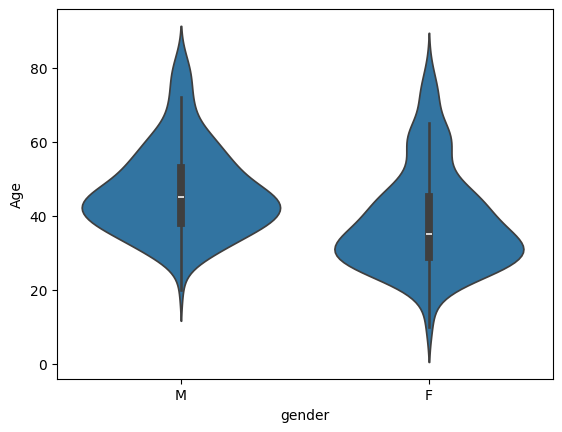

In [26]:
#“¿Existen diferencias en la edad de los actores y actrices ganadores de premios?”
# “Las actrices ganan premios a edades más tempranas que los actores”
sns.violinplot (data=acting[acting["Winner"]==True], x="gender", y='Age')

<Axes: xlabel='gender', ylabel='Age'>

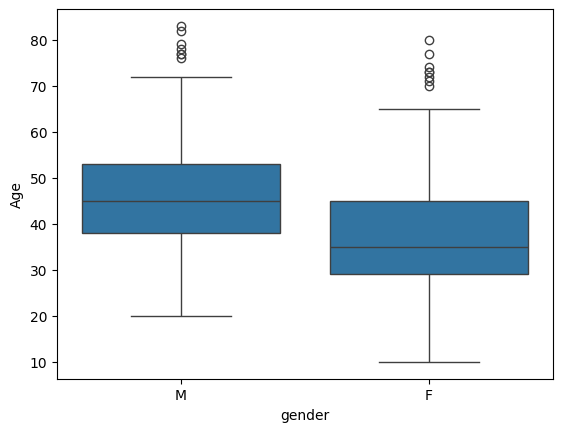

In [27]:
sns.boxplot (data=acting[acting["Winner"]==True], x="gender", y='Age')

In [28]:
import plotly.express as px

fig = px.box(acting[acting["Winner"]==True], 
             x="gender", 
             y="Age",
             title="Distribución de edad en ganadores del Oscar",
             color="gender",
             color_discrete_map={'M': '#4A7FB5', 'F': '#C0392B'})

fig.show()

Parece claro que el violin de las mujeres está bastante más hacia abajo en todo. Para presentación un plotly en el que por encima pueda ir marcando las edades?

In [44]:
#Datos
acting_winners.groupby("gender")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
F,189.0,38.603175,13.428146,10.0,29.0,35.0,45.0,80.0
M,188.0,46.835106,11.813137,20.0,38.0,45.0,53.0,83.0


Text(0.5, 1.0, 'Distribución de edad en ganadores del Oscar')

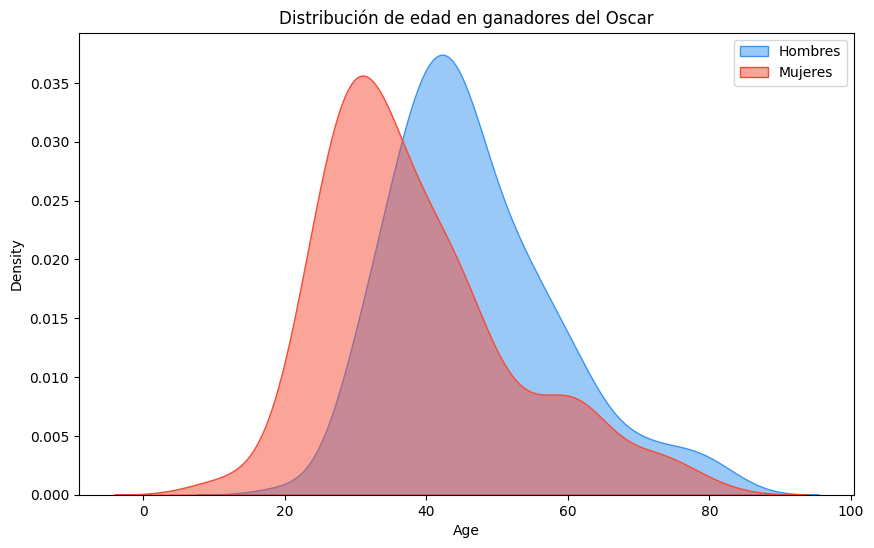

In [29]:
#Para presentar igual mejor un diagrama kde superpuesto
fig, ax = plt.subplots(figsize=(10, 6))

acting_winners = acting[acting['Winner']==True]

sns.kdeplot(data=acting_winners[acting_winners['gender']=='M'], x='Age', fill=True, alpha=0.5, label='Hombres', color="#3894F1")
sns.kdeplot(data=acting_winners[acting_winners['gender']=='F'], x='Age', fill=True, alpha=0.5, label='Mujeres', color="#F64A37")

plt.legend()
plt.title('Distribución de edad en ganadores del Oscar')


In [41]:
import plotly.graph_objects as go
import numpy as np
from scipy.stats import gaussian_kde

acting_winners = acting[acting['Winner']==True]
hombres = acting_winners[acting_winners['gender']=='M']['Age']
mujeres = acting_winners[acting_winners['gender']=='F']['Age']

x = np.linspace(0, 100, 200)
kde_m = gaussian_kde(hombres)(x)
kde_f = gaussian_kde(mujeres)(x)

fig = go.Figure()

fig.add_trace(go.Scatter(x=x, y=kde_m, fill='tozeroy', name='Hombres',
                          fillcolor='rgba(74, 144, 217, 0.3)', 
                          line=dict(color='#4A90D9', width=2)))

fig.add_trace(go.Scatter(x=x, y=kde_f, fill='tozeroy', name='Mujeres',
                          fillcolor='rgba(245, 166, 35, 0.3)', 
                          line=dict(color='#F5A623', width=2)))

fig.update_layout(
    title=dict(text='Distribución de edad en ganadores del Oscar', 
               font=dict(color='white', size=16)),
    xaxis_title='Edad',
    yaxis_title='Densidad',
    plot_bgcolor='#00002e',
    paper_bgcolor='#00002e',
    font=dict(color='white'),
    xaxis=dict(gridcolor='#334155'),
    yaxis=dict(gridcolor='#334155'),
    legend=dict(bgcolor='#00002e', font=dict(color='white'))
)

fig.show()

In [ ]:
#p-value: es estadísticamente significativo? 

from scipy import stats

male = acting[(acting['Winner'] == True) & (acting ['gender'] =='M')]['Age']
female = acting[(acting['Winner'] == True) & (acting ['gender'] =='F')]['Age']

stats.ttest_ind (male, female)

TtestResult(statistic=np.float64(6.3182755438815725), pvalue=np.float64(7.502781802364798e-10), df=np.float64(375.0))

<Axes: xlabel='Age', ylabel='Count'>

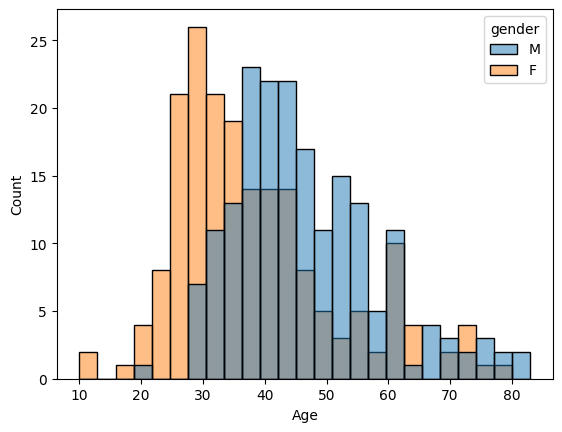

In [32]:
# Es más claro en histograma? _ No
sns.histplot (data=acting [acting['Winner'] == True], x="Age", hue="gender", bins=25)

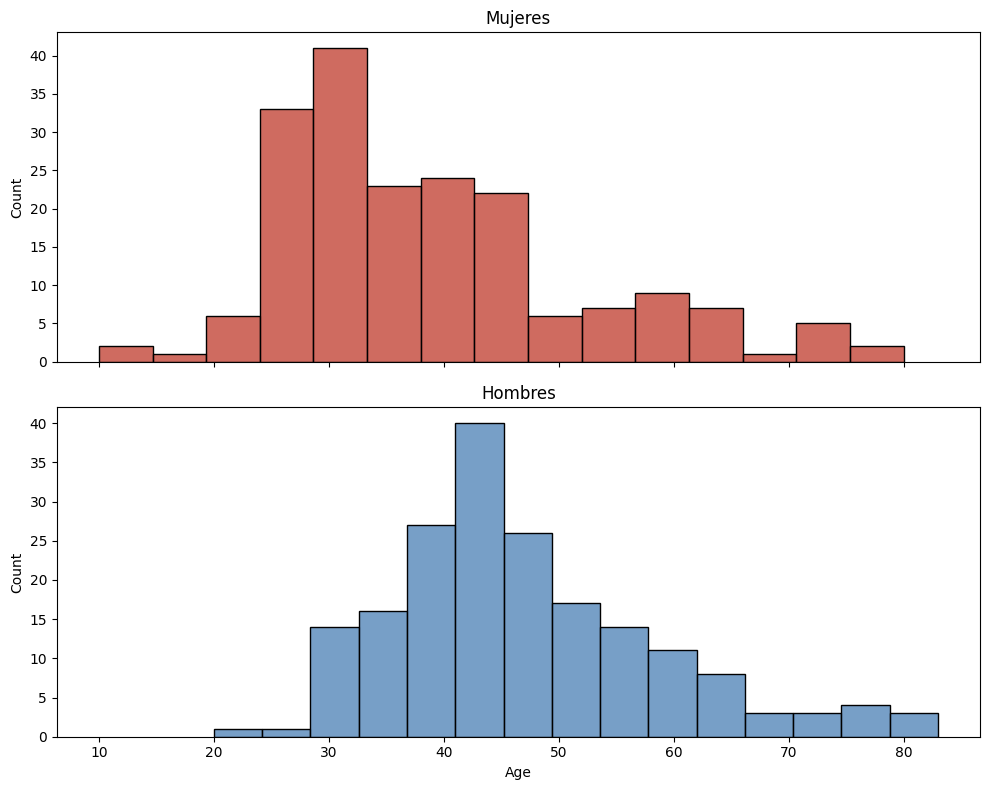

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

sns.histplot(data=acting[(acting['Winner']==True) & (acting['gender']=='F')], 
             x='Age', bins=15, color='#C0392B', ax=axes[0])
axes[0].set_title('Mujeres')

sns.histplot(data=acting[(acting['Winner']==True) & (acting['gender']=='M')], 
             x='Age', bins=15, color='#4A7FB5', ax=axes[1])
axes[1].set_title('Hombres')

plt.tight_layout()





Hacer la distribución temporal. Para ello, voy a calcular la media de edad por década
Comparar con nominados. 

In [34]:
#1929 --> 192*10 --> 1920
acting ["decade"] = acting ["Year"] // 10 * 10

In [35]:
winner_decade = acting [acting ["Winner"] == True].groupby (['decade', 'gender'])["Age"].mean().round(1).reset_index()
#Quitar index

In [36]:
winner_decade

,decade,gender,Age
0,1920,F,25.2
1,1920,M,46.5
2,1930,F,35.2
3,1930,M,40.8
4,1940,F,35.2
5,1940,M,47.2
6,1950,F,37.1
7,1950,M,40.4
8,1960,F,38.1
9,1960,M,46.8


<Axes: xlabel='decade', ylabel='Age'>

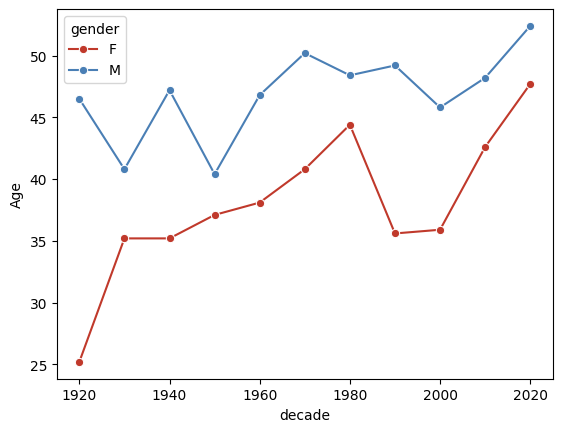

In [37]:
sns.lineplot (data=winner_decade, x="decade", y="Age", hue="gender", 
              palette={'M': '#4A7FB5', 'F': '#C0392B'}, marker='o')

In [45]:
# En plotly para la presentación

import plotly.express as px

fig = px.line(winner_decade, 
              x='decade', 
              y='Age', 
              color='gender',
              markers=True,
              title='Edad media de ganadores del Oscar por década',
              color_discrete_map={'M': '#4A90D9', 'F': '#F5A623'},
              labels={'Age': 'Edad media', 'decade': 'Década', 'gender': 'Género'})

fig.update_layout(
    plot_bgcolor='#00002e',
    paper_bgcolor='#00002e',
    font=dict(color='white'),
    title=dict(font=dict(color='white', size=16)),
    xaxis=dict(gridcolor='#334155'),
    yaxis=dict(gridcolor='#334155'),
    legend=dict(bgcolor='#00002e', font=dict(color='white'))
)

fig.update_traces(line=dict(width=2), marker=dict(size=8))

fig.show()

No hay un patrón claro a lo largo de los años. Sí hay algunas cosas:

- La brecha de edad entre hombres y mujeres se mantiene consistente a lo largo de las décadas, los hombres siempre ganan a mayor edad.
Las actrices ganaban muy jóvenes en los años 20 (media de 25 años) y la tendencia general es al alza, cada vez ganan a edades más maduras.
Los actores se mantienen más estables alrededor de los 45-50.

Es cierto que son sólo 4 ganadores por año (40 por década aprox), con lo cual cualquier patrón extraño (ganador muy joven o muy mayor) altera bastante la media

In [39]:
# Voy a incluir a todos (nominados y ganadores) por ver si hay algo más consistente con más datos
nominees_decade = acting.groupby (['decade', 'gender'])["Age"].mean().round(1).reset_index()

<Axes: xlabel='decade', ylabel='Age'>

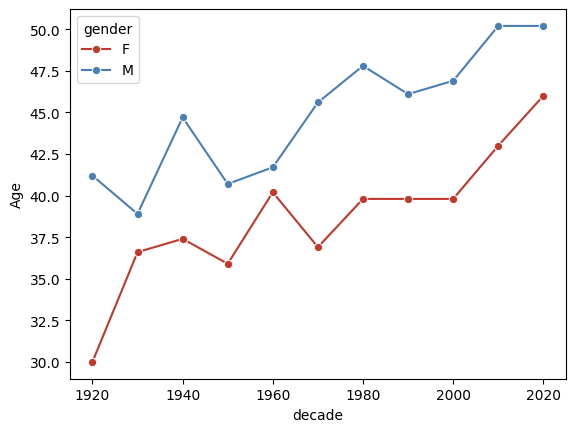

In [40]:
sns.lineplot (data=nominees_decade, x="decade", y="Age", hue="gender", 
              palette={'M': '#4A7FB5', 'F': '#C0392B'}, marker='o')